# NutriClass Project
# Food Classification Using Nutritional Data

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-test split
from sklearn.model_selection import train_test_split, cross_val_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# PCA
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Loading dataset & Display first 5 rows

In [2]:
df = pd.read_csv("../data/synthetic_food_dataset_imbalanced.csv")
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


# Dataset shape

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (31700, 16)


# Column names

In [4]:
df.columns

Index(['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
       'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free',
       'Food_Name'],
      dtype='object')

# Dataset information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

# Missing values

In [6]:
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

# Duplicate rows

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


# Statistical summary

In [8]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


# Filling missing numerical values with median

In [9]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Check missing values again
df.isnull().sum()

Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64

# Check duplicate rows

In [10]:
print("Duplicate Rows Before:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 313
Duplicate Rows After: 0


# Food class distribution

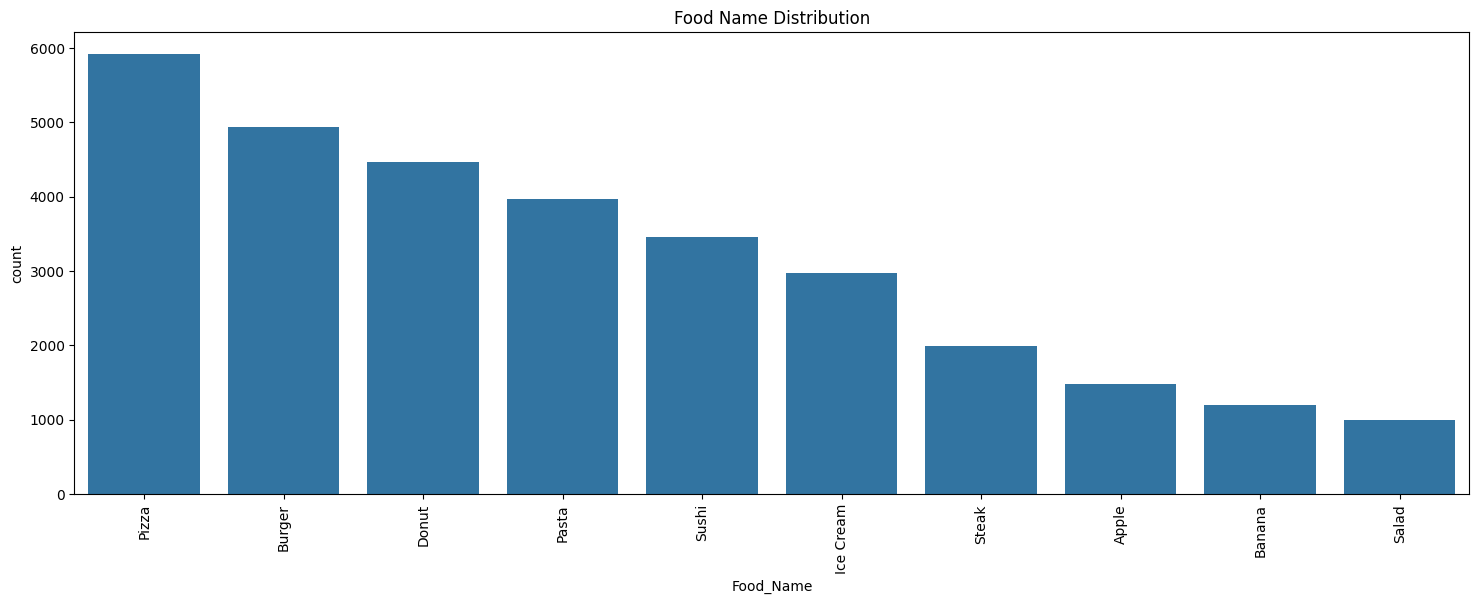

In [11]:
plt.figure(figsize=(18,6))

sns.countplot(x=df['Food_Name'],
              order=df['Food_Name'].value_counts().index)

plt.xticks(rotation=90)
plt.title("Food Name Distribution")
plt.show()

# Histograms for numerical columns

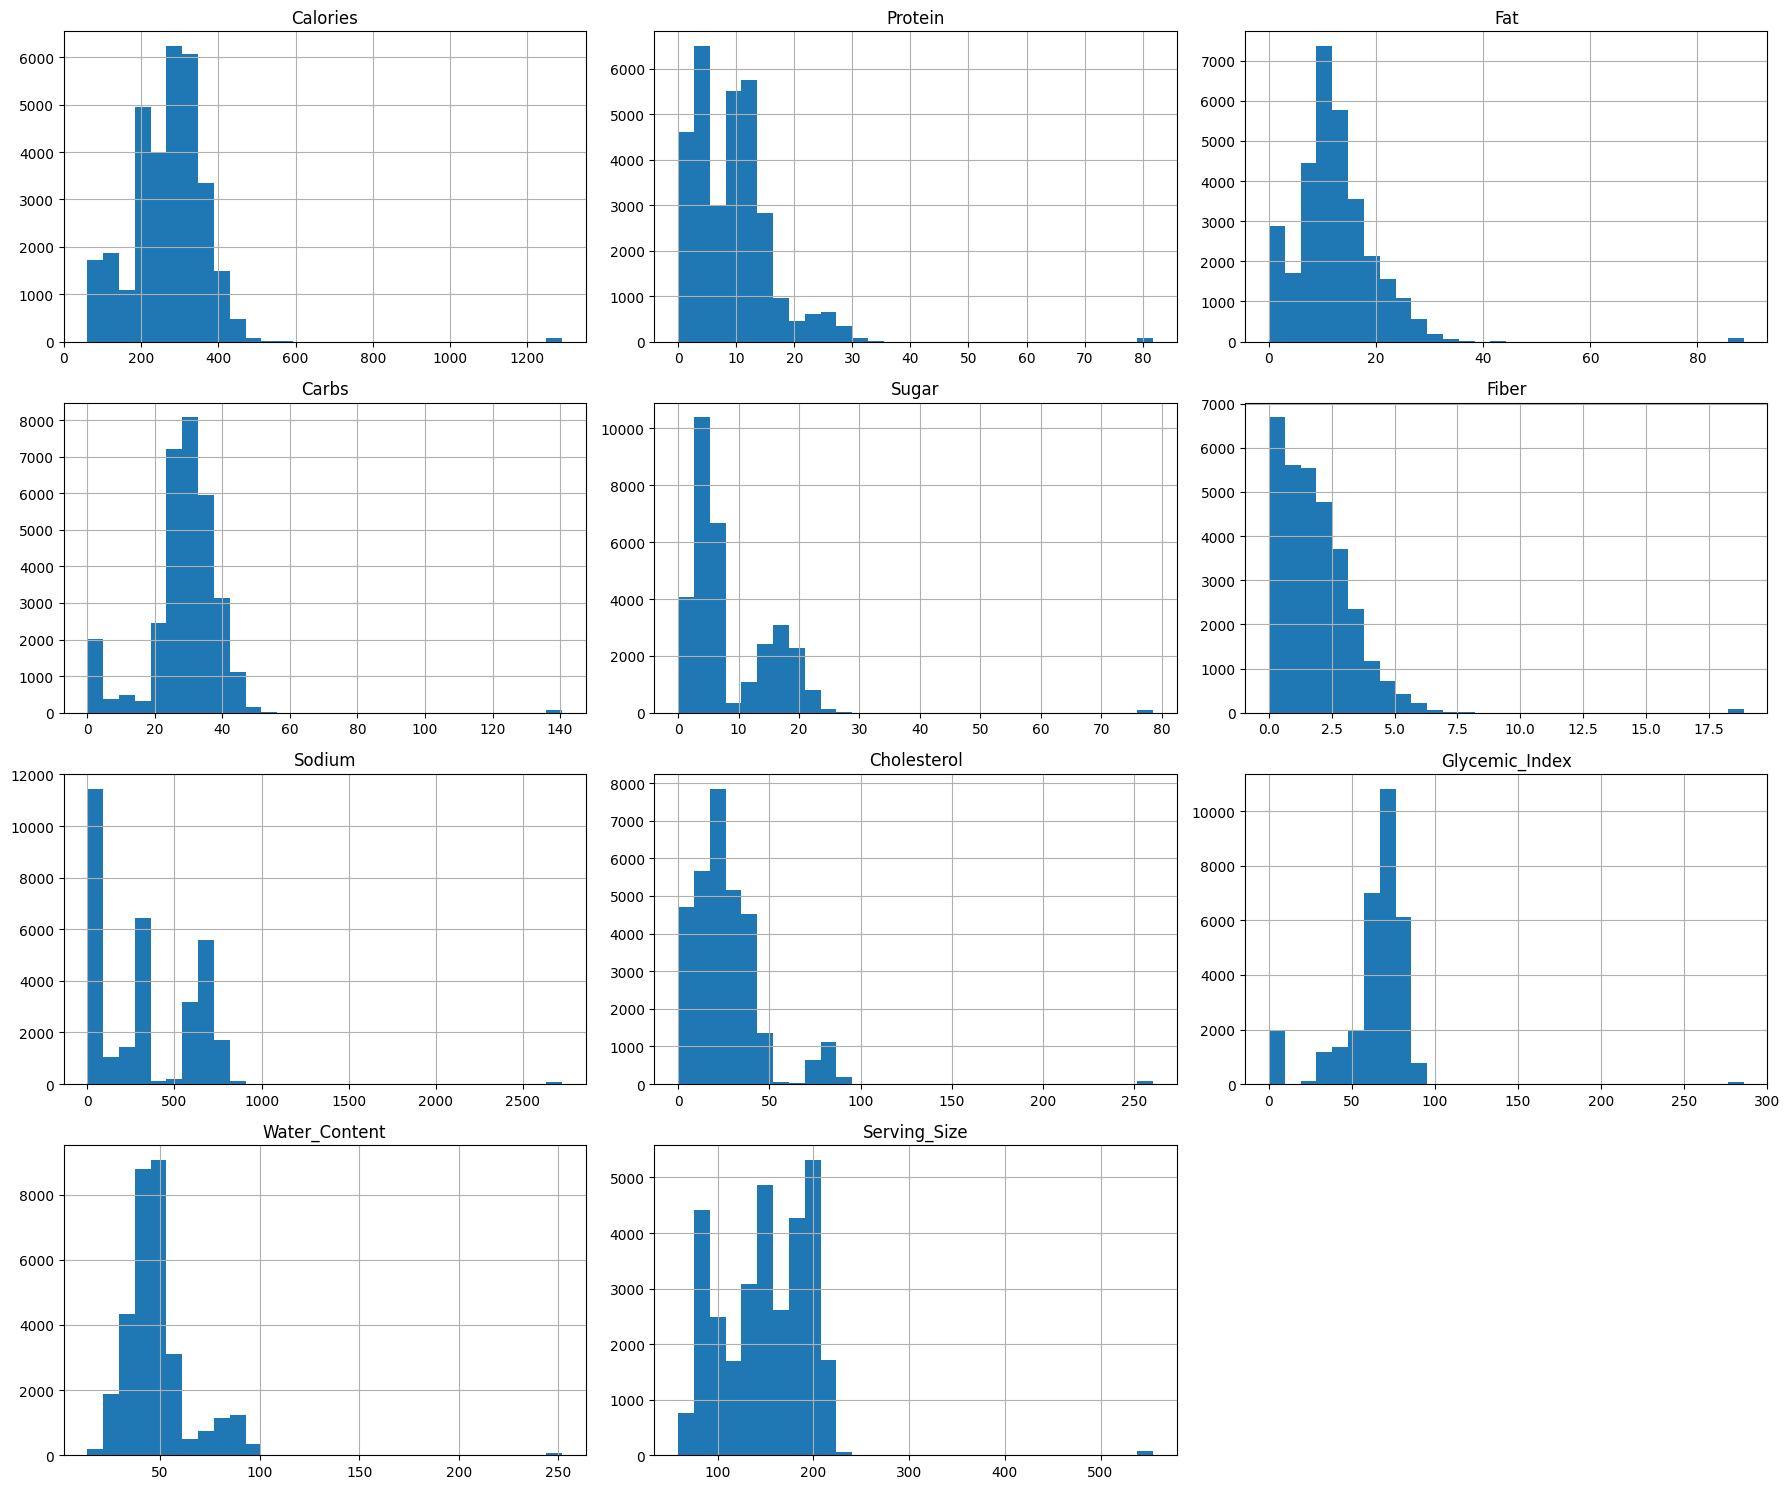

In [12]:
df.hist(figsize=(18,15), bins=30)

plt.tight_layout()
plt.show()

# Correlation heatmap

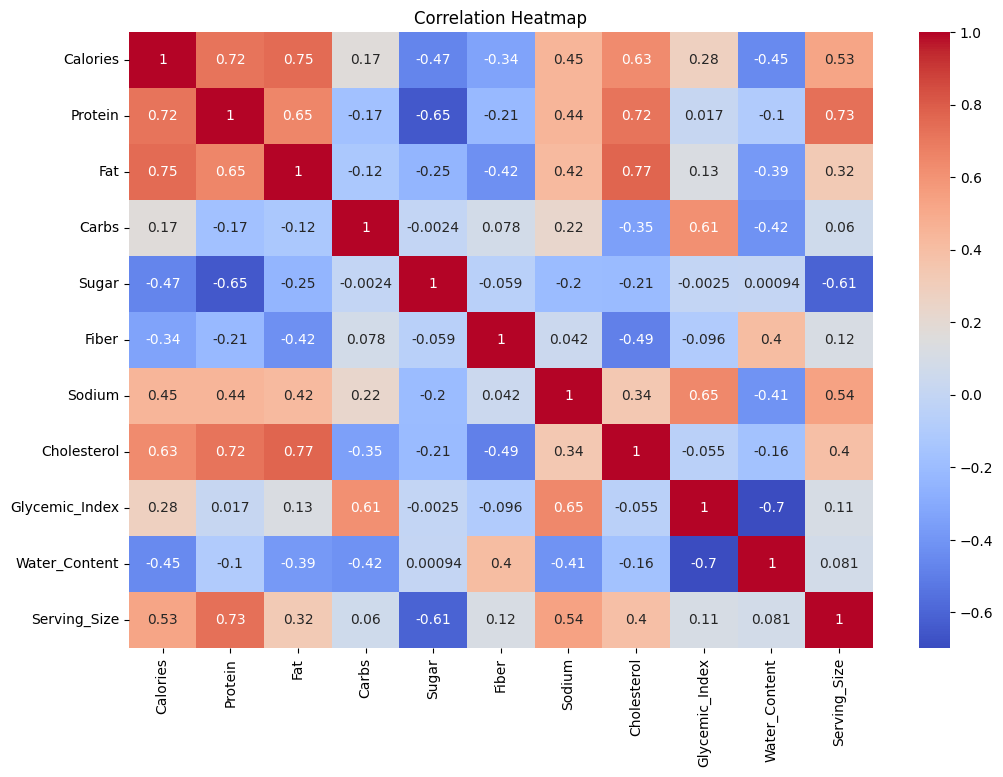

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(df[numeric_columns].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/plots/correlation_heatmap.png"
)

plt.show()

# Outlier treatment using IQR method

In [14]:
for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers
    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])
    
    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])

print("Outlier treatment completed.")

Outlier treatment completed.


# Boxplots after outlier treatment

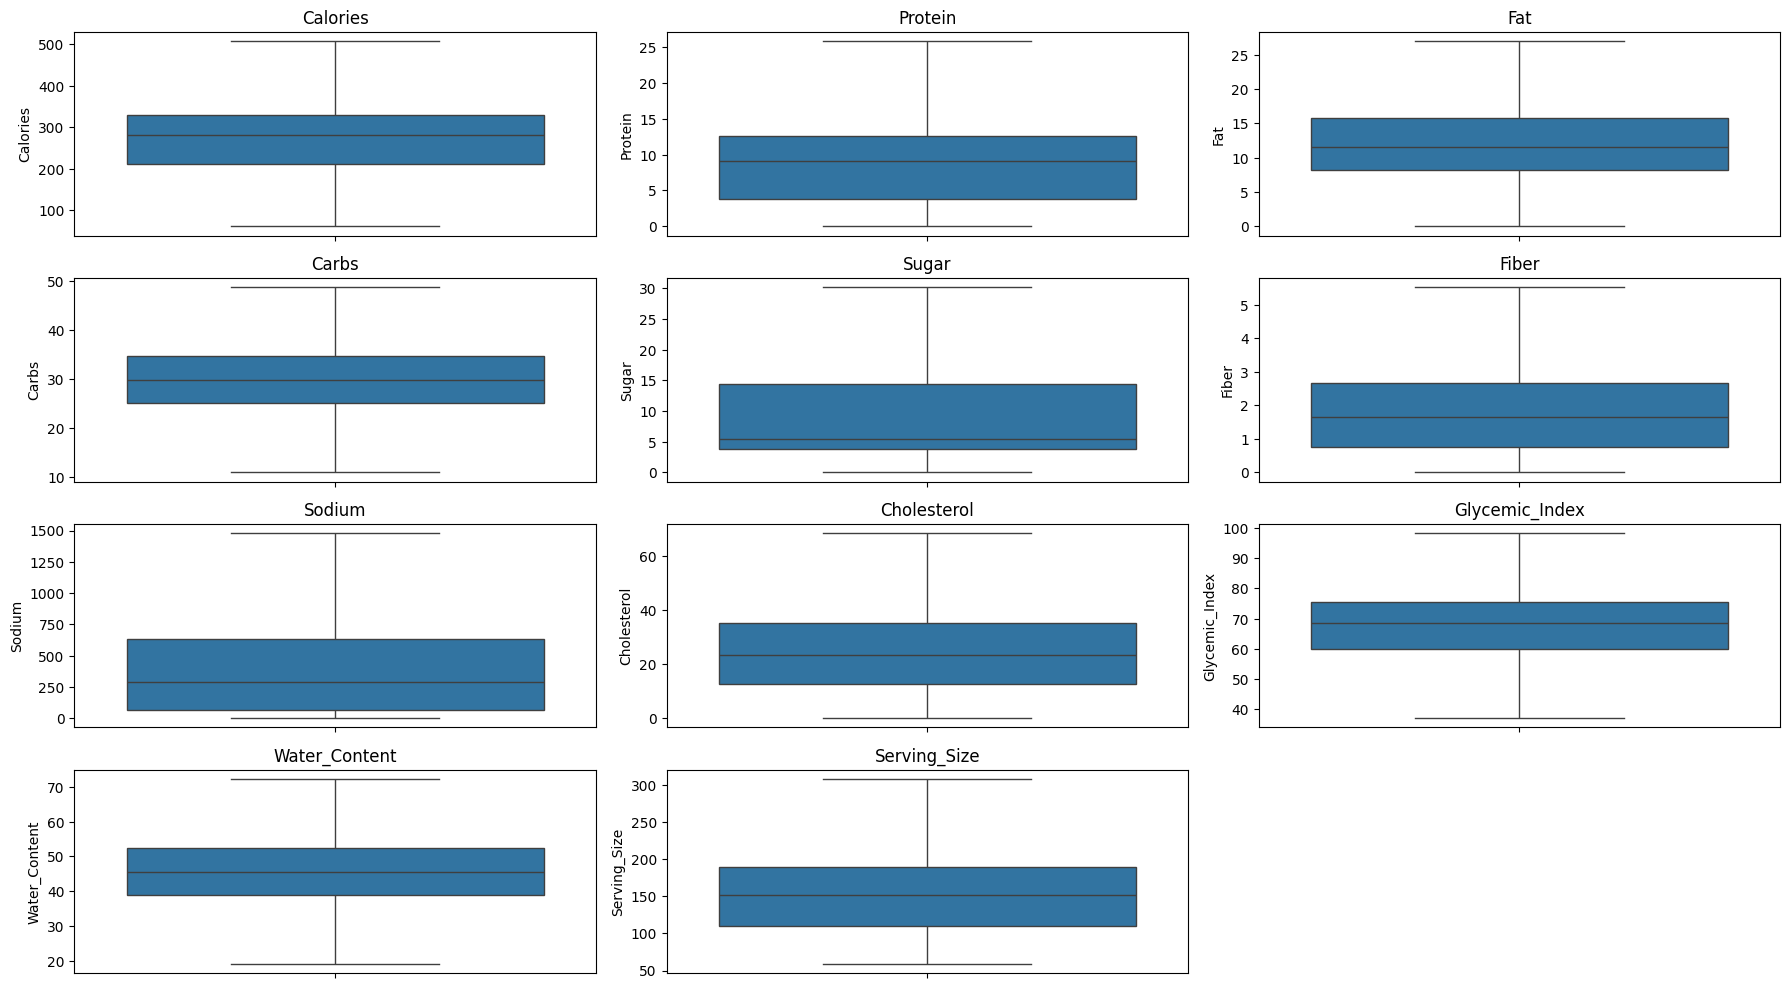

In [15]:
plt.figure(figsize=(18,10))

for i, col in enumerate(numeric_columns):
    
    plt.subplot(4,3,i+1)
    
    sns.boxplot(y=df[col])
    
    plt.title(col)

plt.tight_layout()
plt.show()

# Label Encoding categorical columns

In [16]:
label_encoder = LabelEncoder()

# Encode categorical feature columns
categorical_columns = ['Meal_Type', 'Preparation_Method']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Convert boolean columns into integer
df['Is_Vegan'] = df['Is_Vegan'].astype(int)
df['Is_Gluten_Free'] = df['Is_Gluten_Free'].astype(int)

# Encode target column
df['Food_Name'] = label_encoder.fit_transform(df['Food_Name'])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


# Features and target variable

In [17]:
X = df.drop('Food_Name', axis=1)

y = df['Food_Name']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (31387, 15)
Target Shape: (31387,)


# Feature Scaling

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


# PCA for dimensionality reduction

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (31387, 15)
Reduced Shape: (31387, 2)


# PCA Visualization

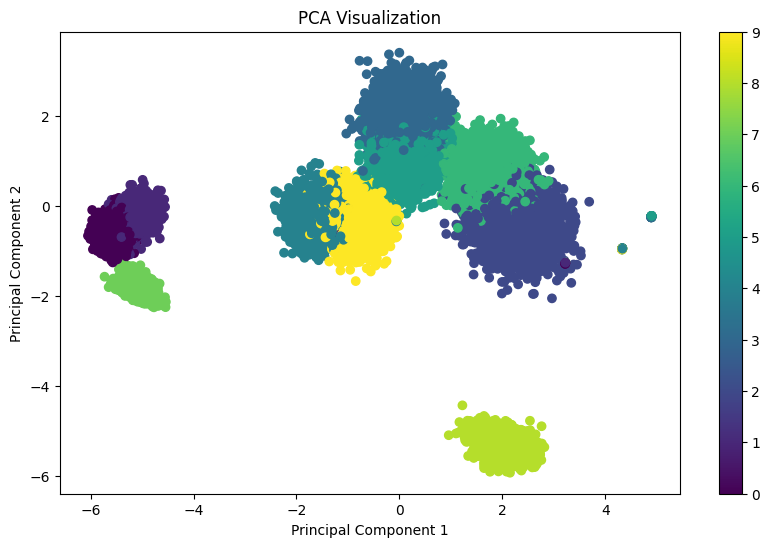

In [35]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.title("PCA Visualization")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)

plt.savefig(
    "../outputs/plots/pca_visualization.png"
)

plt.show()

# Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (25109, 15)
Testing Data Shape: (6278, 15)


# Machine Learning Models

In [24]:
models = {
    
    "Logistic Regression": LogisticRegression(max_iter=500),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(),
    
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Store model results

In [25]:
results = []

# Train and evaluate models

for name, model in models.items():
    
    print("="*50)
    print(f"Training Model: {name}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
    # Print results
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Training Model: Logistic Regression
Accuracy : 0.9920
Precision: 0.9921
Recall   : 0.9920
F1 Score : 0.9920
Training Model: Decision Tree
Accuracy : 0.9849
Precision: 0.9849
Recall   : 0.9849
F1 Score : 0.9849
Training Model: Random Forest
Accuracy : 0.9933
Precision: 0.9933
Recall   : 0.9933
F1 Score : 0.9933
Training Model: KNN
Accuracy : 0.9914
Precision: 0.9914
Recall   : 0.9914
F1 Score : 0.9914
Training Model: SVM
Accuracy : 0.9943
Precision: 0.9943
Recall   : 0.9943
F1 Score : 0.9943
Training Model: XGBoost
Accuracy : 0.9930
Precision: 0.9930
Recall   : 0.9930
F1 Score : 0.9930
Training Model: Gradient Boosting
Accuracy : 0.9935
Precision: 0.9935
Recall   : 0.9935
F1 Score : 0.9935


# Convert results into DataFrame

In [26]:
results_df = pd.DataFrame(results)

# Sort by Accuracy

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,SVM,0.994266,0.994288,0.994266,0.994269
6,Gradient Boosting,0.993469,0.993481,0.993469,0.993469
2,Random Forest,0.993310,0.993315,0.993310,0.993312
5,XGBoost,0.992991,0.993001,0.992991,0.992988
0,Logistic Regression,0.992036,0.992053,0.992036,0.992031
3,KNN,0.991399,0.991416,0.991399,0.991398
1,Decision Tree,0.984868,0.984903,0.984868,0.984871


# Accuracy comparison plot

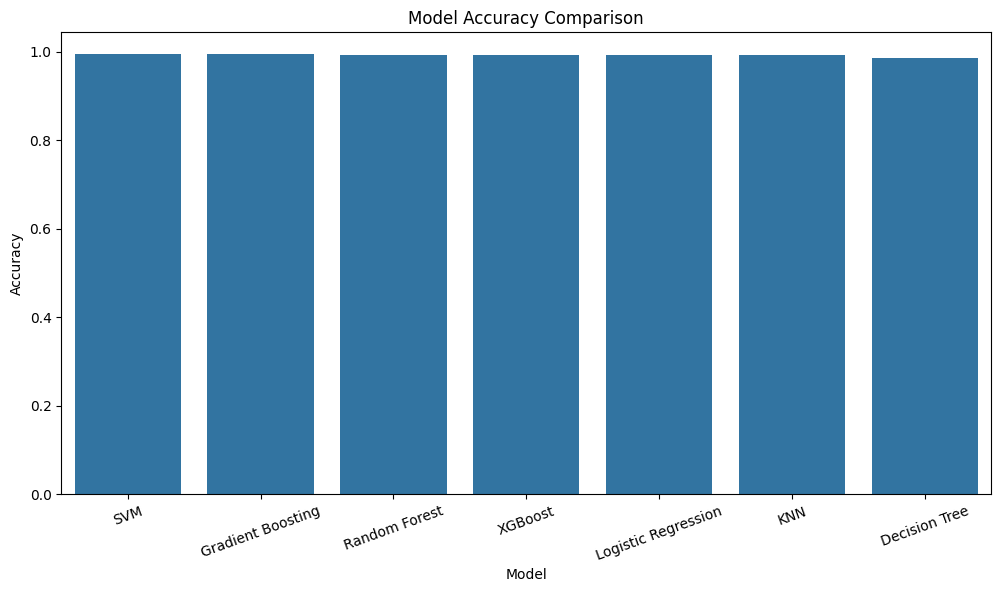

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.savefig(
    "../outputs/plots/model_accuracy_comparison.png"
)

plt.show()

# Final Best Model - SVM

In [28]:
final_model = SVC()

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("Final SVM Model Trained Successfully")

Final SVM Model Trained Successfully


# Classification Report

In [29]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       297
           1       0.99      0.99      0.99       239
           2       1.00      0.99      0.99       988
           3       1.00      1.00      1.00       893
           4       1.00      1.00      1.00       594
           5       0.99      0.99      0.99       795
           6       0.99      0.99      0.99      1183
           7       1.00      0.99      1.00       199
           8       1.00      1.00      1.00       398
           9       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



# Confusion Matrix

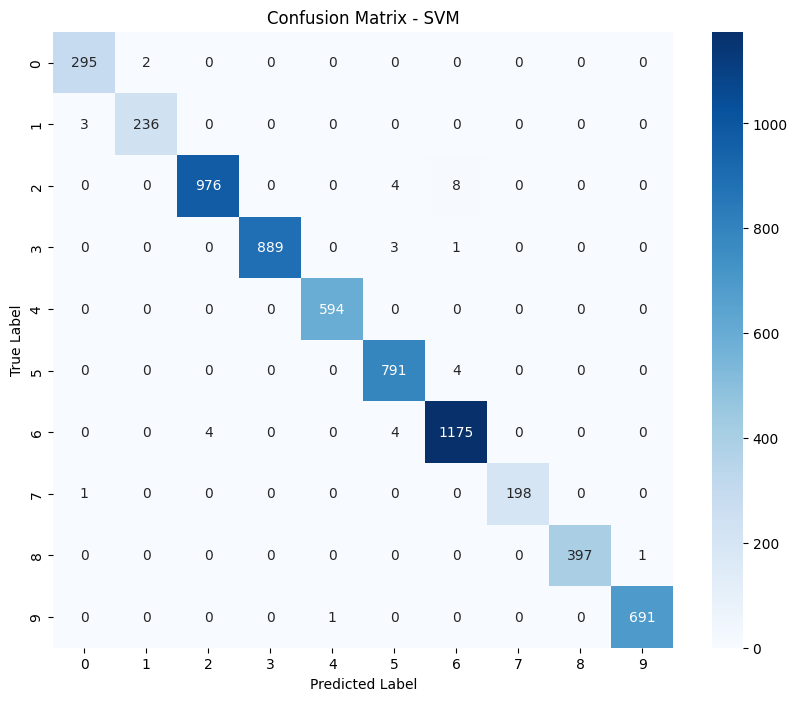

In [30]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - SVM")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Cross Validation

In [31]:
cv_scores = cross_val_score(
    final_model,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.98837209 0.99171711 0.99346822 0.9945834  0.99601721]
Average CV Score: 0.9928316046136569


# Feature Importance using Random Forest

In [32]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

,Feature,Importance
6,Sodium,0.167144
10,Serving_Size,0.119797
7,Cholesterol,0.116441
4,Sugar,0.107421
14,Is_Gluten_Free,0.093513
8,Glycemic_Index,0.080491
1,Protein,0.062665
0,Calories,0.058466
9,Water_Content,0.052643
2,Fat,0.051306


# Feature Importance Plot

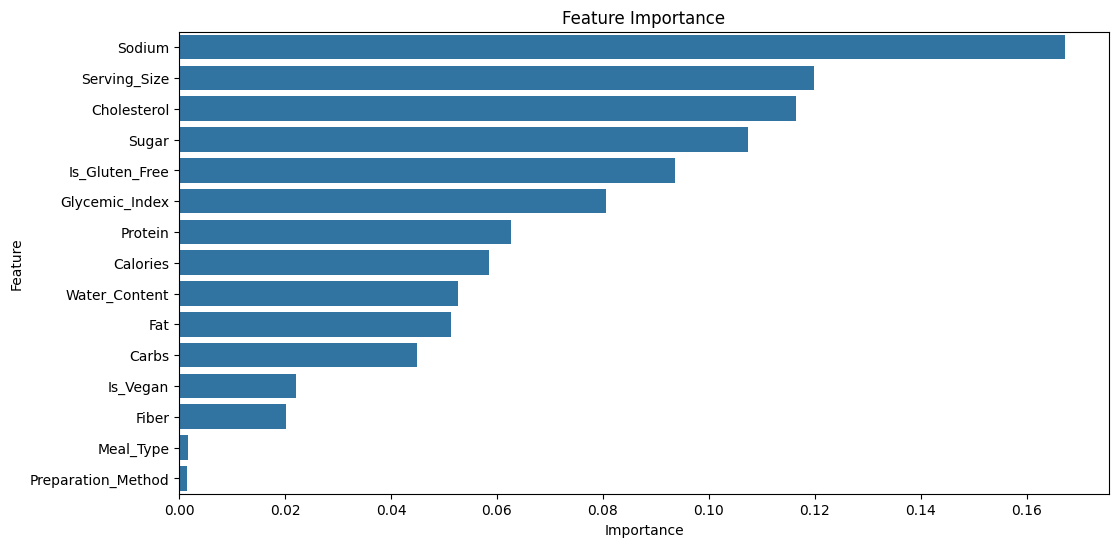

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance")

plt.savefig(
    "../outputs/plots/feature_importance.png"
)

plt.show()

# Conclusion

# In this project, a food classification system was developed using nutritional data and multiple machine learning algorithms.

# The dataset was preprocessed by handling missing values, removing duplicate entries, treating outliers using the IQR method, encoding categorical variables, and scaling features using StandardScaler.

# Exploratory Data Analysis (EDA) was performed using histograms, heatmaps, class distribution plots, and PCA visualization to better understand the dataset structure and feature relationships.

# Several machine learning models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, XGBoost, and Gradient Boosting.

# Among all models, the Support Vector Machine (SVM) achieved the best performance with approximately 99.43% accuracy and excellent precision, recall, and F1-score values.

# Cross-validation results also confirmed the robustness and stability of the model.

# The project successfully demonstrates how machine learning techniques can accurately classify food items based on nutritional attributes.

# SAVING SVM MODEL

In [34]:
import joblib

# Save trained SVM model

joblib.dump(
    final_model,
    "../outputs/models/svm_model.pkl"
)

print("SVM model saved successfully.")

SVM model saved successfully.
